# Vendite e Qualità del Prodotto: Due Casi di Studio in Machine Learning

Questo notebook raccoglie un'analisi end-to-end su due dataset distinti, affrontando tre delle principali categorie di problemi nel Machine Learning supervisionato e non supervisionato.

**Dataset utilizzati:**
- **supermarket_sales** — 1.000 transazioni presso filiali di supermercati: usato per regressione e analisi delle serie temporali.
- **apple_quality** — caratteristiche fisiche e organolettiche di 4.000 mele: usato per classificazione e clustering.

Il notebook è strutturato in due parti indipendenti, una per ciascun dataset.

---

## Librerie


In [2]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

---
# Parte 1 — Supermarket Sales

Il dataset `supermarket_sales` contiene dati relativi a 1.000 transazioni effettuate in tre filiali di una catena di supermercati. L'obiettivo di questa sezione è duplice: costruire modelli di regressione per predire il **Rating** delle transazioni e analizzare l'**andamento temporale** del gross income.


In [4]:
regression_raw_dataset = pd.read_csv('supermarket_sales.csv')

## Esplorazione del dataset

Il dataset viene prima visualizzato in forma tabellare per un'ispezione visiva, poi analizzato tramite `.info()` per verificare tipi di dato, valori nulli e dimensioni.

In [6]:
regression_raw_dataset.head(100)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,594-34-4444,A,Yangon,Normal,Male,Electronic accessories,97.16,1,4.8580,102.0180,3/8/2019,20:38,Ewallet,97.16,4.761905,4.8580,7.2
96,766-85-7061,B,Mandalay,Normal,Male,Health and beauty,87.87,10,43.9350,922.6350,3/29/2019,10:25,Ewallet,878.70,4.761905,43.9350,5.1
97,871-39-9221,C,Naypyitaw,Normal,Female,Electronic accessories,12.45,6,3.7350,78.4350,2/9/2019,13:11,Cash,74.70,4.761905,3.7350,4.1
98,865-92-6136,A,Yangon,Normal,Male,Food and beverages,52.75,3,7.9125,166.1625,3/23/2019,10:16,Ewallet,158.25,4.761905,7.9125,9.3


In [7]:
regression_raw_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

Non sono presenti valori nulli. Alcune colonne risultano però non pertinenti per la predizione — come l'ID fattura, data, ora e margine — e vengono eliminate. Le colonne rimanenti sono quelle effettivamente utili al modello.

In [9]:
regression_dataset = regression_raw_dataset.drop(columns=['Invoice ID', 'Tax 5%', 'Total', 'Date', 'Time', 'cogs', 'gross margin percentage'])

In [10]:
regression_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Branch         1000 non-null   object 
 1   City           1000 non-null   object 
 2   Customer type  1000 non-null   object 
 3   Gender         1000 non-null   object 
 4   Product line   1000 non-null   object 
 5   Unit price     1000 non-null   float64
 6   Quantity       1000 non-null   int64  
 7   Payment        1000 non-null   object 
 8   gross income   1000 non-null   float64
 9   Rating         1000 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 78.3+ KB


## Analisi descrittiva del Rating

La colonna `Rating` è la variabile target: nel contesto di questa analisi rappresenta una valutazione della redditività della transazione per la catena di supermercati. Si calcolano media, mediana e moda per avere una prima sintesi della distribuzione.

In [12]:
# codice per calcolare la media, mediana e moda della label "Rating"
from scipy import stats

ratings = regression_dataset['Rating'].to_numpy()

# 1. Media
media = np.mean(ratings)

# 2. Mediana
mediana = np.median(ratings)

# 3. Moda
# Usando scipy
moda_risultato = stats.mode(ratings, keepdims=True)
moda = moda_risultato.mode[0]
frequenza = moda_risultato.count[0]

print(f"Media: {media:.2f}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda} (appare {frequenza} volte)")

Media: 6.97
Mediana: 7.0
Moda: 6.0 (appare 26 volte)


Media e mediana sono molto vicine, segno che la distribuzione è simmetrica e priva di valori estremi. La moda a 6.0 è però più bassa della media: una parte consistente delle transazioni si attesta su una valutazione appena sufficiente, suggerendo margini di miglioramento nella redditività.

La deviazione standard indica che il 68% dei rating cade nell'intervallo $[5.25,\ 8.69]$ ($Media \pm 1\sigma$): c'è una discreta eterogeneità nei valori.

In [14]:
# codice per calcolare la deviazione standard della label "Rating"
std_dev = np.std(ratings)

print(f"Deviazione Standard: {std_dev:.2f}")

Deviazione Standard: 1.72


## Distribuzione della variabile target e del gross income

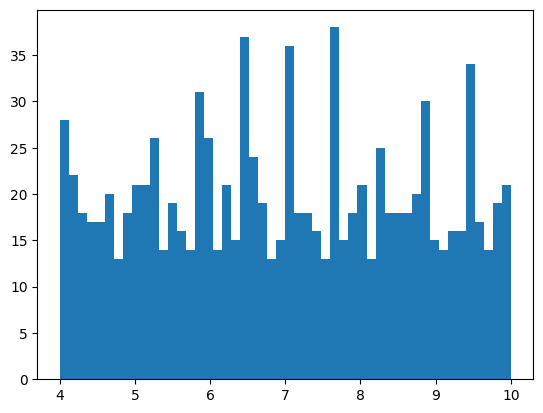

In [16]:
plt.hist(regression_dataset['Rating'], 50)
plt.show()

La distribuzione dei rating è sostanzialmente uniforme, senza skewness rilevante. Diverso il caso del gross income:

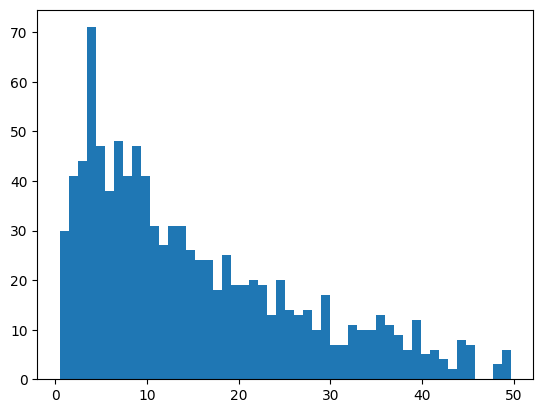

In [18]:
plt.hist(regression_dataset['gross income'], 50)
plt.show()

Qui invece la skewness c'è e la maggioranza degli ordini sembra avere un income lordo basso.
Qual è, quindi, il valore di questa skewness esattamente? 

In [20]:
# Codice per calcolare la skewness del gross income
from scipy.stats import skew

# Trasforma la colonna in un array numpy
gross_income = regression_dataset['gross income'].to_numpy()

# Calcolo della skewness
valore_skewness = skew(gross_income)

print(f"Skewness del gross income: {valore_skewness:.4f}")

Skewness del gross income: 0.8912


Come ci si aspettava dal grafico, la skewness  è positiva, poiché la coda è verso destra. Questo significa che la maggior parte delle vendite genera un profitto medio basso, però c'è una minoranza delle vendite che genera un profitto alto. Questa minoranza è rappresentata appunto dalla coda.
Considerando che i dati riguardano un supermercato, la situazione rappresentata non risulta anomala, è normale infatti avere numerosi acquisti di articoli piccoli e poco costosi (alimenti) e pochi acquisti di articoli molto costosi (potrebbero essere elettrodomestici, pentole, altri accessori da cucina).

## Preprocessing: encoding, scaling e split

Le variabili categoriche (`Branch`, `City`, `Customer type`, `Gender`, `Product line`, `Payment`) non possono essere usate direttamente dagli algoritmi e vanno trasformate in vettori numerici. Si applica **Label Encoding** per `Gender` e **One-Hot Encoding** per le restanti.

In [23]:
# codice per effettuare l'enconding delle variabili categoriche

# 1. Label Encoding per Gender
regression_dataset['Gender'] = regression_dataset['Gender'].astype('category').cat.codes

# 2. One-Hot Encoding per le altre variabili
cols_to_encode = ['Branch', 'City', 'Customer type', 'Product line', 'Payment']
regression_dataset = pd.get_dummies(regression_dataset, columns=cols_to_encode, drop_first=True)

print(regression_dataset.head())

   Gender  Unit price  Quantity  gross income  Rating  Branch_B  Branch_C  \
0       0       74.69         7       26.1415     9.1     False     False   
1       0       15.28         5        3.8200     9.6     False      True   
2       1       46.33         7       16.2155     7.4     False     False   
3       1       58.22         8       23.2880     8.4     False     False   
4       1       86.31         7       30.2085     5.3     False     False   

   City_Naypyitaw  City_Yangon  Customer type_Normal  \
0           False         True                 False   
1            True        False                  True   
2           False         True                  True   
3           False         True                 False   
4           False         True                  True   

   Product line_Fashion accessories  Product line_Food and beverages  \
0                             False                            False   
1                             False                     

`Unit price` e `gross income` presentano scale molto diverse tra loro; quest'ultimo ha anche una distribuzione asimmetrica. Entrambe le colonne vengono standardizzate con **StandardScaler** per evitare che dominino artificialmente i modelli basati su distanze o gradienti.

In [25]:
# codice per effettuare la standardizzazione della colonna "Unit price" e "gross income"
from sklearn.preprocessing import StandardScaler

# Inizializzazione dello scaler
scaler = StandardScaler()

# Selezione colonne da trasformare
cols_to_scale = ['Unit price', 'gross income']

# Trasformazione
regression_dataset[cols_to_scale] = scaler.fit_transform(regression_dataset[cols_to_scale])

print(regression_dataset[cols_to_scale].head())

   Unit price  gross income
0    0.718160      0.919607
1   -1.525303     -0.987730
2   -0.352781      0.071446
3    0.096214      0.675780
4    1.156959      1.267125


I dati vengono divisi in **training set** (80%) e **test set** (20%) prima dell'addestramento. Lo split è randomizzato con `random_state=42` per garantire la riproducibilità dei risultati.

In [27]:
from sklearn.model_selection import train_test_split

# codice per splittare il dataset in training set e test set

# 1. Definizione variabile target (y) e features (X)

y = regression_dataset['Rating']
X = regression_dataset.drop('Rating', axis=1)

# 2. Effettuiamo lo split 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)

# Verifica delle dimensioni
print(f"Dimensioni Training set: {X_train.shape}")
print(f"Dimensioni Test set: {X_test.shape}")

Dimensioni Training set: (800, 16)
Dimensioni Test set: (200, 16)


## Regressione lineare

Si parte dal modello più semplice come baseline di riferimento.

In [29]:
# training del modello con la linear regression
from sklearn.linear_model import LinearRegression

# 1. Creazione del modello
regressor = LinearRegression()

# 2. Addestramento
regressor.fit(X_train, y_train)

# 3. Predizione (il modello mette alla prova ciò che ha imparato sul test set)
y_pred = regressor.predict(X_test)

Le metriche di valutazione sono **MSE** e **MAE**, le principali per problemi di regressione.

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calcolo delle metriche
MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)

# Stampa delle metriche richieste
print('MSE =', MSE, '\nMAE =', MAE)

MSE = 3.1101872910260715 
MAE = 1.5229214208487525


Significa che il modello può sbagliare di circa 1.5 punti a predire il voto dei clienti. Si può considerare discreto come risultato.

## Regressione polinomiale

Si prova ad aggiungere complessità trasformando le feature in polinomi di grado 2, ipotizzando che le relazioni tra variabili non siano puramente lineari.

In [34]:
# training del modello con la polynomial regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Creazione dell'oggetto per trasformare le feature in polinomiali
poly_regressor = PolynomialFeatures(degree=2)

# 2. Trasformazione delle feature (sia train che test)
X_train_poly = poly_regressor.fit_transform(X_train)
X_test_poly = poly_regressor.transform(X_test)

# 3. Creazione e addestramento del modello lineare sulle nuove feature
regressor = LinearRegression()
regressor.fit(X_train_poly, y_train)

# 4. Predizione
y_pred_poly = regressor.predict(X_test_poly)

In [35]:
# 1. Calcolo del Mean Absolute Error (MAE)
MAE_poly = mean_absolute_error(y_test, y_pred_poly)

# 2. Calcolo del Mean Squared Error (MSE)
MSE_poly = mean_squared_error(y_test, y_pred_poly)

print(f"--- Performance Modello Polinomiale ---")
print('MSE_poly =', MSE_poly, '\nMAE_poly =', MAE_poly)

--- Performance Modello Polinomiale ---
MSE_poly = 3.452618857644124 
MAE_poly = 1.56929965306118


I valori di MSE e MAE sono più grandi di prima, quindi il modello polinomiale non funziona meglio in questo caso. Probabilmente perché le variabili da cui è influenzato il rating sono categoriche e un modello polinomiale lavora meglio su variabili numeriche continue.

## Random Forest

Si testa infine un modello ensemble, più robusto rispetto ai precedenti su dati con feature eterogenee.

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Inizializza il modello (100 alberi decisionali)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Addestra
rf_model.fit(X_train, y_train)

# Predici
y_pred_rf = rf_model.predict(X_test)

# Valuta
print(f"MAE Random Forest: {mean_absolute_error(y_test, y_pred_rf)}")
print(f"MSE Random Forest: {mean_squared_error(y_test, y_pred_rf)}")

MAE Random Forest: 1.6149949999999997
MSE Random Forest: 3.5733233749999993


I risultati sono leggermente peggiori rispetto alla regressione lineare. Per capire perché, si analizza la **feature importance**: potrebbe esserci una colonna indirettamente correlata al calcolo del rating che distorce il modello.

<Axes: >

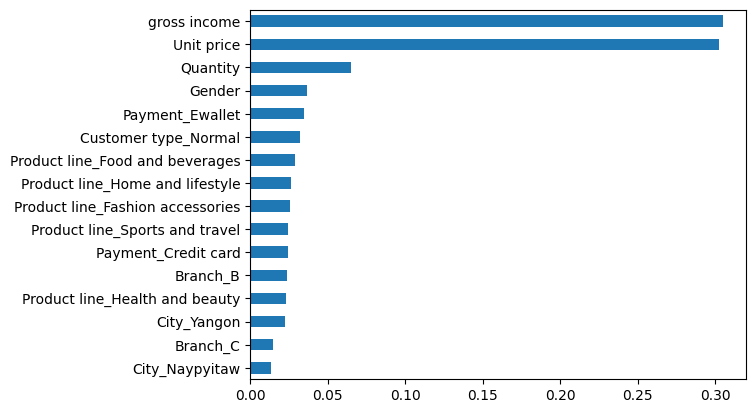

In [40]:
pd.Series(rf_model.feature_importances_, index=X.columns).sort_values().plot(kind='barh')

Sembra probabile che il rating sia stato calcolato a partire da quantity e Unit Price e che non sia una valutazione del cliente scollegata dagli altri campi del dataset.


## Analisi delle serie temporali

Nella sezione precedente l'informazione temporale è stata scartata perché non utile a predire il Rating. Qui viene invece recuperata per rispondere a una domanda diversa: **è possibile prevedere l'andamento del gross income nel tempo?**

Si costruisce un sottoinsieme del dataset originale con sole le colonne `Date` e `gross income`.

In [43]:
# codice per costruire un nuovo dataset, partendo da regression_raw_dataset, con solo le colonne "Date" e "gross income"
timeseries_dataset = regression_raw_dataset[['Date', 'gross income']].copy()

In [44]:
timeseries_dataset.head(100)

,Date,gross income
0,1/5/2019,26.1415
1,3/8/2019,3.8200
2,3/3/2019,16.2155
3,1/27/2019,23.2880
4,2/8/2019,30.2085
...,...,...
95,3/8/2019,4.8580
96,3/29/2019,43.9350
97,2/9/2019,3.7350
98,3/23/2019,7.9125


Come primo approccio si testa la **regressione lineare**, per verificare se esiste un trend lineare nel gross income al crescere del tempo.

In [46]:
# Preparazione dei dati
from datetime import datetime

# 'Date' in formato datetime
timeseries_dataset['Date'] = pd.to_datetime(timeseries_dataset['Date'])

# Dati in ordine per data (fondamentale per le serie temporali)
timeseries_dataset = timeseries_dataset.sort_values('Date')

# Converte le date in numeri ordinali
# Questo permette al modello di calcolare la pendenza rispetto ai giorni
X = timeseries_dataset['Date'].map(datetime.toordinal).values.reshape(-1, 1)
y = timeseries_dataset['gross income'].values


In [47]:
# training della time series con la linear regression

# Inizializza e addestra il modello
model = LinearRegression()
model.fit(X, y)

# Genera le previsioni (la linea di regressione)
y_pred = model.predict(X)

print(f"Coefficiente (Pendenza): {model.coef_[0]}")
print(f"Intercetta: {model.intercept_}")

Coefficiente (Pendenza): -0.010672696072520018
Intercetta: 7882.26637752958


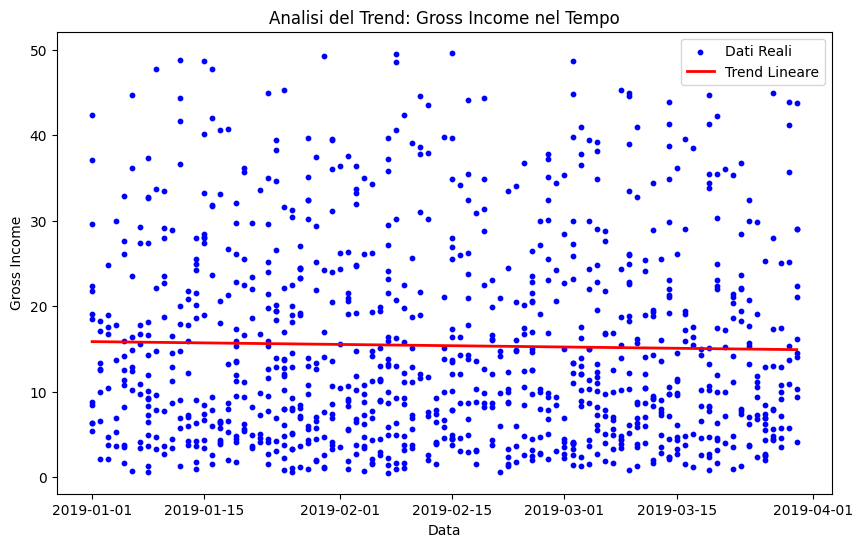

In [48]:
plt.figure(figsize=(10, 6))
plt.scatter(timeseries_dataset['Date'], y, color='blue', label='Dati Reali', s=10)
plt.plot(timeseries_dataset['Date'], y_pred, color='red', linewidth=2, label='Trend Lineare')
plt.xlabel('Data')
plt.ylabel('Gross Income')
plt.title('Analisi del Trend: Gross Income nel Tempo')
plt.legend()
plt.show()

Dal grafico non emerge un trend lineare evidente: il gross income potrebbe avere andamenti ciclici legati al giorno della settimana o alla stagione, che una retta non è in grado di catturare.

In [50]:
# Calcoliamo le previsioni sul nostro set di dati
y_pred = model.predict(X)

# Calcolo delle metriche
MSE_ts = mean_squared_error(y, y_pred)
MAE_ts = mean_absolute_error(y, y_pred)

print('MSE Serie Temporale =', MSE_ts, '\nMAE Serie Temporale =', MAE_ts)

MSE Serie Temporale = 136.8876806798879 
MAE Serie Temporale = 9.615855455467681


In [51]:
# Per capire come sono i risultati
media_income = timeseries_dataset['gross income'].mean()
print(f"Media gross income: {media_income}")

Media gross income: 15.379369


Il MAE di 9.6 su un income medio di 15.4 è altissimo: il modello sbaglia in misura proporzionalmente molto grande. Come ci si aspettava, la regressione lineare non è adatta a questa serie temporale. La vicinanza tra MAE e $\sqrt{MSE}$ indica che gli errori sono distribuiti uniformemente nel dataset, senza outlier dominanti.

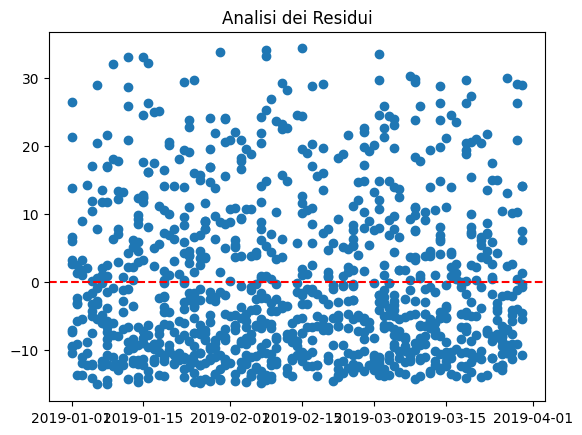

In [53]:
# residui. Se gli errori seguono uno schema il modello è troppo semplice
residui = y - y_pred
plt.scatter(timeseries_dataset['Date'], residui)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Analisi dei Residui")
plt.show()

In [54]:
r2 = model.score(X, y)
print(f"R-quadrato: {r2:.4f}")

R-quadrato: 0.0005


L'R² è prossimo a zero: la data non spiega la varianza del gross income. I guadagni dipendono da altri fattori, non da un trend temporale.

## Serie temporali con XGBoost

Si sostituisce la regressione lineare con XGBoost, un modello ensemble basato su gradient boosting, per verificare se un algoritmo più potente riesce a trovare pattern temporali che la regressione lineare non coglie.

In [57]:
# Training e performance evalutation della time series con XGBoost
import xgboost as xgb

# Creazione feature temporali
df = timeseries_dataset.copy()
df['day_of_week'] = df['Date'].dt.dayofweek
df['day_of_month'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Definizione X (features) e y (target)
X = df[['day_of_week', 'day_of_month', 'month', 'is_weekend']]
y = df['gross income']

# Split dei dati: importante non mescolare il futuro con il passato
# Usa shuffle=False per mantenere l'ordine cronologico
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [58]:
# Inizializzazione del modello
# n_estimators: numero di alberi, max_depth: profondità dell'albero
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, objective='reg:squarederror')

# Addestramento
xgb_model.fit(X_train, y_train)

# Previsioni
y_pred_xgb = xgb_model.predict(X_test)

In [59]:
# confronto con le metriche ottenute prima
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MAE_xgb = mean_absolute_error(y_test, y_pred_xgb)
MSE_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"--- Risultati XGBoost ---")
print(f"MAE_xgb: {MAE_xgb:.2f}")
print(f"MSE_xgb: {MSE_xgb:.2f}")
print(f"R-quadrato: {r2_xgb:.4f}")

--- Risultati XGBoost ---
MAE_xgb: 9.55
MSE_xgb: 138.00
R-quadrato: -0.0641


Anche XGBoost produce un R² negativo: il modello performa peggio della semplice media dei dati. MAE e MSE rimangono analoghi a quelli della regressione lineare, confermando che il gross income non presenta dipendenza temporale. Il problema non è il modello, ma l'assenza di struttura nel dato.

Si approfondisce la questione con una **heatmap di correlazione** per identificare quali variabili del dataset originale sono effettivamente legate al gross income.

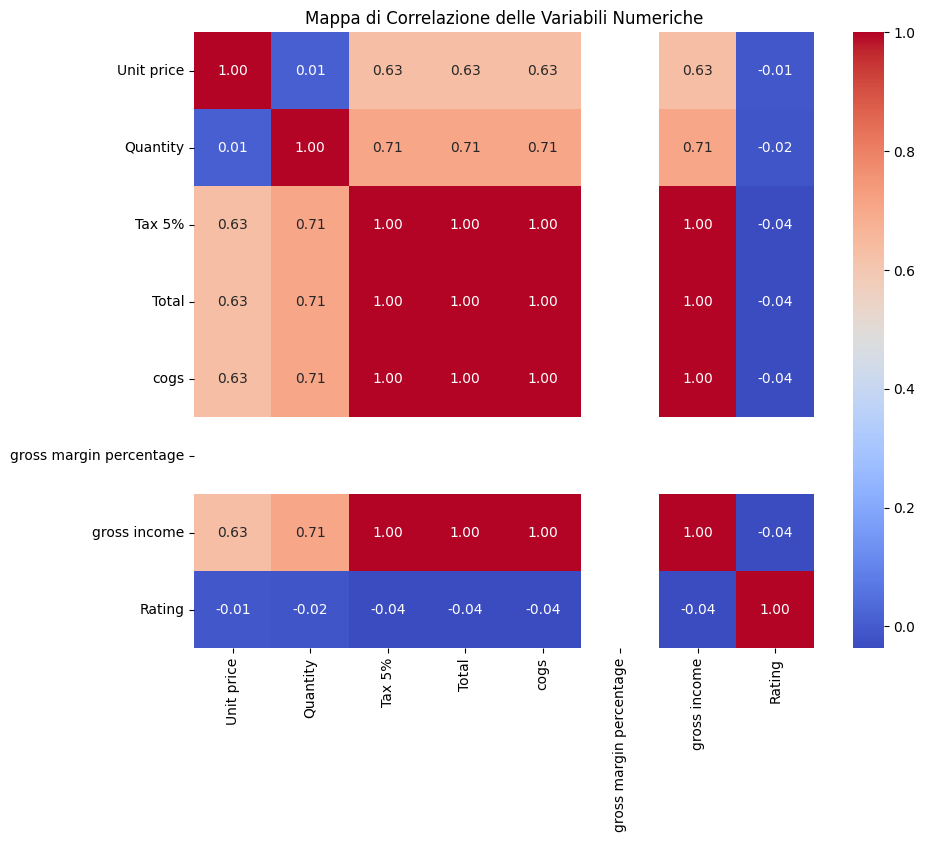

In [62]:
import seaborn as sns
# Seleziona solo le colonne numeriche (int e float)
numeric_df = regression_raw_dataset.select_dtypes(include=['float64', 'int64'])

# Ora calcola la correlazione
plt.figure(figsize=(10, 8))
correlation_matrix = numeric_df.corr()

# Disegna la heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mappa di Correlazione delle Variabili Numeriche")
plt.show()


`Unit price` e `Quantity` mostrano correlazione elevata con il gross income. Si costruisce un modello XGBoost usando queste variabili — più le categoriche `Product line` e `City` — per capire se la relazione è davvero predittiva.

In [64]:
# 1. Preparazione il dataset con le variabili forti + variabili categoriche
# One-Hot Encoding per trasformare le colonne categoriche in colonne numeriche (0/1)
features = ['Unit price', 'Quantity', 'Product line', 'City']
X = pd.get_dummies(regression_raw_dataset[features], drop_first=True)
y = regression_raw_dataset['gross income']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Training con XGBoost
final_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6)
final_model.fit(X_train, y_train)

# 4. Evaluation
y_pred = final_model.predict(X_test)
print(f"Nuovo R-quadrato: {r2_score(y_test, y_pred):.4f}")
print(f"Nuovo MAE: {mean_absolute_error(y_test, y_pred):.2f}")

Nuovo R-quadrato: 0.9990
Nuovo MAE: 0.27


Un R² così alto rivela che il gross income in questo dataset **non è una grandezza osservata** ma il risultato di un calcolo aritmetico:

$$Gross\ Income = (Unit\ Price \times Quantity) \times \text{Margine Profitto}$$

Non serve un modello per prevederlo: basta applicare la formula. Una variabile target più utile in un contesto reale sarebbe la **quantità venduta**, che riflette il comportamento dei clienti e può guidare le decisioni di rifornimento.

In [66]:
# Ricrea il DataFrame 'df' partendo dal dataset originale
# Include sia le colonne per le feature che la Date per creare i tempi
cols_to_use = ['Date', 'Quantity', 'Product line', 'City', 'Customer type']
df = regression_raw_dataset[cols_to_use].copy()

# 2. Ricrea le feature temporali
df['Date'] = pd.to_datetime(df['Date'])
df['day_of_week'] = df['Date'].dt.dayofweek
df['month'] = df['Date'].dt.month
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Selezione feature: Tempo + Categorie
features_qty = ['day_of_week', 'month', 'is_weekend', 'Product line', 'City', 'Customer type']

# Trasformazione categorie in numeri (One-Hot Encoding)
X_qty = pd.get_dummies(df[features_qty], drop_first=True)
y_qty = df['Quantity']

# Split dei dati
X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(X_qty, y_qty, test_size=0.2, random_state=42)

# Training con XGBoost
model_qty = xgb.XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=5)
model_qty.fit(X_train_q, y_train_q)

# Previsioni e Metriche
y_pred_q = model_qty.predict(X_test_q)

print(f"R-quadrato per Quantity: {r2_score(y_test_q, y_pred_q):.4f}")
print(f"MAE per Quantity: {mean_absolute_error(y_test_q, y_pred_q):.2f}")

R-quadrato per Quantity: -0.1588
MAE per Quantity: 2.52


R² negativo: città, giorno e categoria merceologica non permettono di prevedere quanti articoli verranno venduti. Le quantità acquistate dai clienti non mostrano dipendenza da queste variabili.

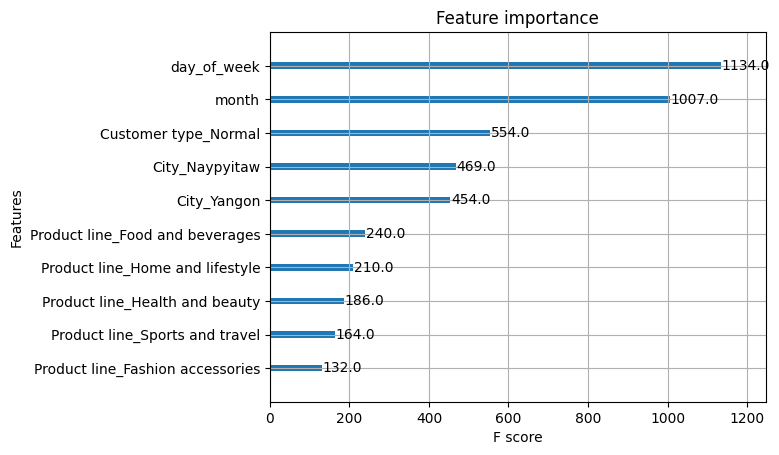

In [68]:
xgb.plot_importance(model_qty)
plt.show()

XGBoost individua una dipendenza dal giorno della settimana e dal mese, ma il modello fallisce comunque sul test set. Si verifica se le medie per giorno della settimana siano effettivamente diverse.

In [70]:
# Controllo se la media cambia davvero per giorno della settimana
print(df.groupby('day_of_week')['Quantity'].mean())

# E per mese
print(df.groupby('month')['Quantity'].mean())

day_of_week
0    5.104000
1    5.455696
2    5.594406
3    5.471014
4    5.453237
5    5.603659
6    5.849624
Name: Quantity, dtype: float64
month
1    5.582386
2    5.458746
3    5.481159
Name: Quantity, dtype: float64


Le medie giornaliere variano tra 5.1 (lunedì) e 5.8 (domenica), una differenza esistente ma minima. All'interno di ogni singolo giorno i valori oscillano comunque da 1 a 10: il segnale è troppo debole per costruire un modello affidabile sul singolo cliente. Si cambia prospettiva e si prova a prevedere le **vendite totali giornaliere** del negozio.

In [72]:
cols_to_use = ['Date', 'Quantity', 'gross income']
df = regression_raw_dataset[cols_to_use].copy()
df['Date'] = pd.to_datetime(df['Date'])

# Crezione il dataset giornaliero
daily_df = df.groupby('Date').agg({
    'Quantity': 'sum',
    'gross income': 'sum'
}).reset_index()

# Feature temporali sul nuovo dataset
daily_df['day_of_week'] = daily_df['Date'].dt.dayofweek
daily_df['month'] = daily_df['Date'].dt.month
daily_df['day'] = daily_df['Date'].dt.day

print(f"Il nuovo dataset ha {len(daily_df)} giorni.")

Il nuovo dataset ha 89 giorni.


Il dataset copre circa 90 giorni: dopo lo split, il training set conta circa 70 giorni, un numero molto ridotto per addestrare un modello sulle serie temporali.

In [74]:
# Feature e Target
X_daily = daily_df[['day_of_week', 'month', 'day']]
y_daily = daily_df['Quantity']

# Split (mantenendo l'ordine cronologico)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_daily, y_daily, test_size=0.2, shuffle=False)

# XGBoost
daily_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05)
daily_model.fit(X_train_d, y_train_d)

# Previsioni e R_quadro
y_pred_d = daily_model.predict(X_test_d)
print(f"R_quadro Giornaliero: {r2_score(y_test_d, y_pred_d):.4f}")

R_quadro Giornaliero: -0.7861


L'R² è ancora negativo. Si visualizzano le vendite giornaliere per verificare se esiste un pattern visivo che il modello potrebbe non riuscire a catturare.

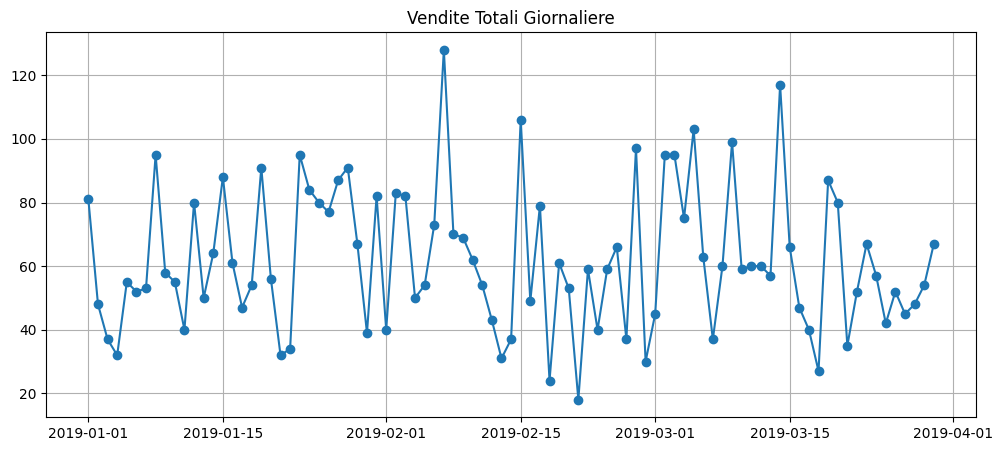

In [76]:
plt.figure(figsize=(12, 5))
plt.plot(daily_df['Date'], daily_df['Quantity'], marker='o')
plt.title("Vendite Totali Giornaliere")
plt.grid(True)
plt.show()

Sembra non ci sia nessuna dipendenza dalla data, solo molte fluttuazioni. Si può dedurre che:
- non è necessario fare scorte diverse tra lunedì e domenica;

- non si notano stagionalità mensili evidenti;

- il successo del negozio dipende da fattori esterni al dataset (meteo, promozioni, concorrenza).

Come ultimo tentativo si aggiunge una **rolling average a 3 giorni** come feature. L'idea è fornire al modello un contesto sul trend recente: se le vendite stanno crescendo o calando, questa informazione potrebbe migliorare la predizione.

In [79]:
# Creazione le feature di memoria
daily_df['ieri'] = daily_df['Quantity'].shift(1)
daily_df['media_3_giorni'] = daily_df['Quantity'].shift(1).rolling(window=3).mean()

# Rimozione dei primi giorni che avranno valori NaN (perché non hanno un 'ieri')
df_memory = daily_df.dropna()

# Definizione le feature incluse quelle storiche
X_mem = df_memory[['day_of_week', 'month', 'day', 'ieri', 'media_3_giorni']]
y_mem = df_memory['Quantity']

# Split cronologico
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_mem, y_mem, test_size=0.2, shuffle=False)

# Allenamento
model_mem = xgb.XGBRegressor(n_estimators=50, learning_rate=0.05)
model_mem.fit(X_train_m, y_train_m)

# Risultati
y_pred_m = model_mem.predict(X_test_m)
print(f"R-quadrato con Memoria: {r2_score(y_test_m, y_pred_m):.4f}")

R-quadrato con Memoria: -0.2347


R² ancora negativo. I volumi di vendita non presentano dipendenza temporale rilevabile con i dati disponibili: le fluttuazioni sembrano dominate da variabili esterne non censite nel dataset.

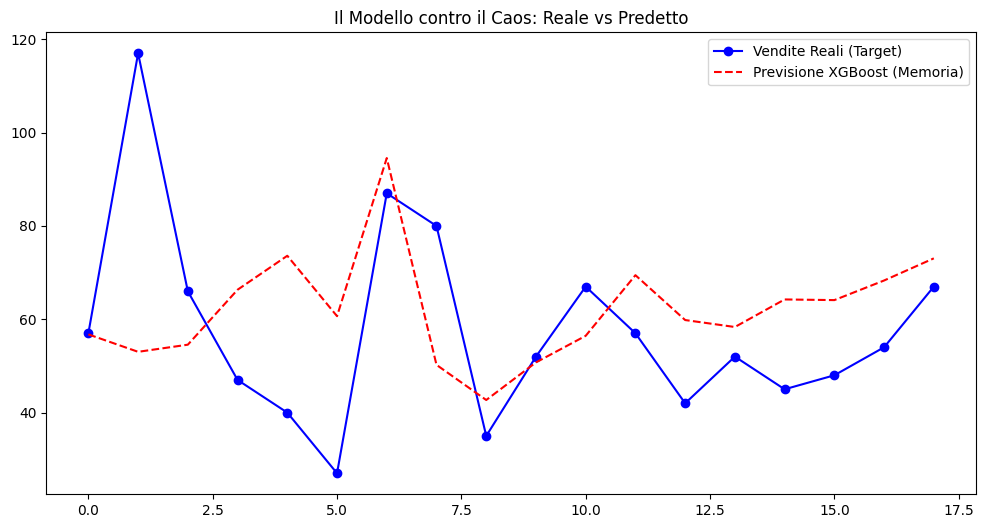

In [81]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_m.values, label='Vendite Reali (Target)', color='blue', marker='o')
plt.plot(y_pred_m, label='Previsione XGBoost (Memoria)', color='red', linestyle='--')
plt.title("Il Modello contro il Caos: Reale vs Predetto")
plt.legend()
plt.show()

## Analisi del gross income per categoria merceologica

Si conclude l'analisi del dataset supermarket_sales verificando se alcune categorie di prodotto generano profitti significativamente superiori alle altre.

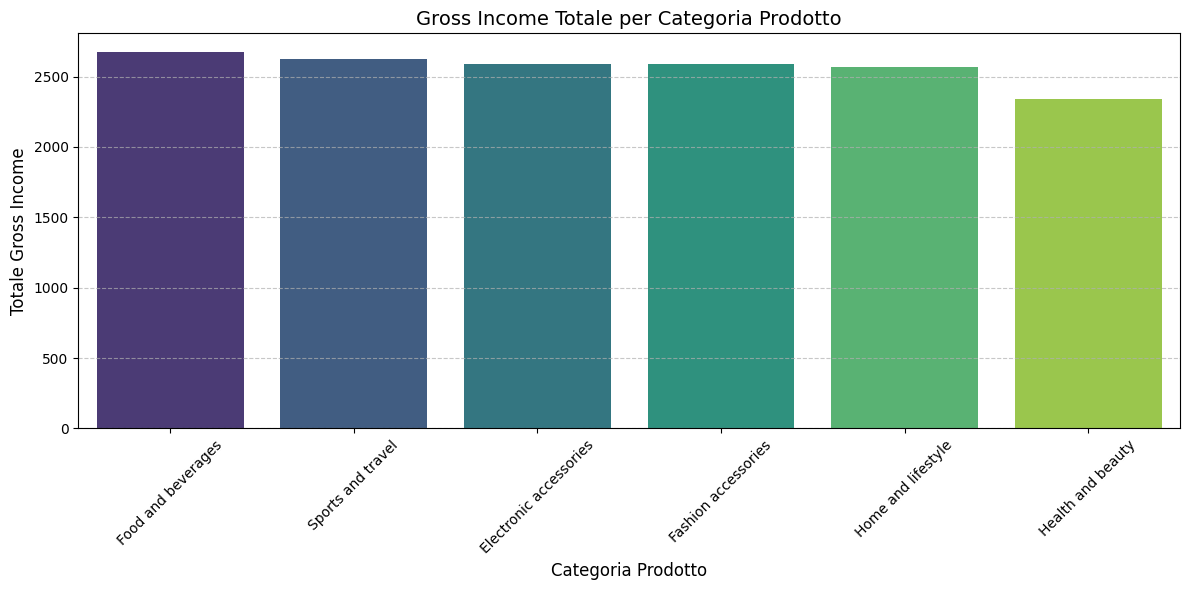

             Product line  gross income
0      Food and beverages     2673.5640
1       Sports and travel     2624.8965
2  Electronic accessories     2587.5015
3     Fashion accessories     2585.9950
4      Home and lifestyle     2564.8530
5       Health and beauty     2342.5590


In [83]:
# 1. Calcolo della classifica
top_products = regression_raw_dataset.groupby('Product line')['gross income'].sum().sort_values(ascending=False).reset_index()

# 2. Grafico a barre verticali
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_products,
    x='Product line',
    y='gross income',
    hue='Product line',
    palette='viridis',
    legend=False
)

# 3. Formattazione estetica
plt.title('Gross Income Totale per Categoria Prodotto', fontsize=14)
plt.xlabel('Categoria Prodotto', fontsize=12)
plt.ylabel('Totale Gross Income', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(top_products)

La distribuzione del gross income tra le categorie è sostanzialmente equilibrata. Food & Beverage è in leggero vantaggio, coerentemente con la natura di un supermercato dove gli acquisti alimentari sono i più frequenti.

---
# Parte 2 — Apple Quality

Il dataset `apple_quality` descrive le caratteristiche fisiche e organolettiche (dimensione, peso, dolcezza, croccantezza, succosità, maturazione, acidità) di 4.000 mele, ciascuna etichettata come **good** o **bad**. L'obiettivo è costruire modelli in grado di classificare automaticamente la qualità delle mele, con potenziali applicazioni nella selezione della merce in arrivo a un punto vendita.

Si esplorano sia approcci **supervisionati** (Logistic Regression, Decision Tree) sia **non supervisionati** (K-Means Clustering).


## Logistic Regression

Si parte dal modello di classificazione lineare di riferimento.

In [87]:
# codice per importare il dataset apple_quality
classification_dataset = pd.read_csv('apple_quality.csv')

In [88]:
# codice per print delle prime 50 righe
classification_dataset.head(50)

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good
5,5.0,-3.425400,-1.409082,-1.913511,-0.555775,-3.853071,1.914616,-2.981523169,bad
6,6.0,1.331606,1.635956,0.875974,-1.677798,3.106344,-1.847417,2.414170509,good
7,7.0,-1.995462,-0.428958,1.530644,-0.742972,0.158834,0.974438,-1.470125066,good
8,8.0,-3.867632,-3.734514,0.986429,-1.207655,2.292873,4.080921,-4.871904758,bad
9,9.0,-0.727983,-0.442820,-4.092223,0.597513,0.393714,1.620857,2.185607723,bad


In [89]:
# codice per visualizzare i principali metadata del dataset apple_quality
classification_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   float64
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4001 non-null   object 
 8   Quality      4000 non-null   object 
dtypes: float64(7), object(2)
memory usage: 281.4+ KB


Il dataset è già pulito e quasi interamente numerico. L'unica eccezione è la label `Quality` (good/bad), che viene encodata in valori binari (1/0). Si rimuove poi la colonna `A_id` (identificatore senza valore predittivo) e si applica **StandardScaler** prima dello split 80/20 con stratificazione sulla label.

In [91]:
# codice per effettuare l'enconding della label "Quality"

classification_dataset['Quality'] = classification_dataset['Quality'].map({'good': 1, 'bad': 0})

In [92]:
# codice per splittare in train/test il dataset apple_quality
from sklearn.preprocessing import StandardScaler

# Rimuove l'ultima riga se contiene valori nulli o testo nella colonna ID
classification_dataset = classification_dataset.dropna()

# Rimuove Quality (target) e A_id dalle feature
X = classification_dataset.drop(['Quality', 'A_id'], axis=1, errors='ignore')
y = classification_dataset['Quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Usa StandardScaler per portare tutto alla stessa media (0) e deviazione standard (1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Campioni totali: {len(X)}")
print(f"Training set: {X_train.shape[0]} campioni")
print(f"Test set: {X_test.shape[0]} campioni")



Campioni totali: 4000
Training set: 3200 campioni
Test set: 800 campioni


In [93]:
# codice per trainare il modello usando la logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Creazione del modello
logistic_regressor = LogisticRegression(max_iter=1000)

# 2. Addestramento
logistic_regressor.fit(X_train, y_train)

# 3. Predizione
y_pred = logistic_regressor.predict(X_test)

Come metrica principale si usa l'**F1 score**, che bilancia precision e recall ed è più informativa dell'accuracy su dataset con classi potenzialmente sbilanciate.

In [95]:
from sklearn.metrics import classification_report

y_predict_test = logistic_regressor.predict(X_test)

print(classification_report(y_test, y_predict_test))

              precision    recall  f1-score   support

         0.0       0.76      0.71      0.74       399
         1.0       0.73      0.77      0.75       401

    accuracy                           0.74       800
   macro avg       0.74      0.74      0.74       800
weighted avg       0.74      0.74      0.74       800



F1 è molto simile per 0.0 e 1.0, significa che le classi sono bilanciate. L'accuracy al 74% indica che il modello ha capito abbastanza bene come sono divise le mele, ma c'è comunque un 26 % di errore dovuto al fatto che le relazioni tra le variabili non sono lineari. Probabilmente, mettendo le mele su un grafico, queste non possono essere separate da una retta senza commettere qualche errore.

Si analizza la **confusion matrix** per capire dove il modello sbaglia: quante mele cattive vengono erroneamente classificate come buone (falsi positivi) e quante mele buone vengono scartate (falsi negativi).

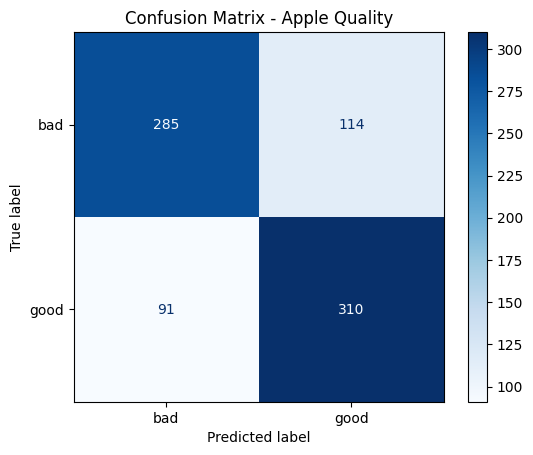

In [98]:
# codice per la confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Calcolo della matrice di confusione
cm = confusion_matrix(y_test, y_predict_test)

# 2. Visualizzazione grafica
# Usa 0 per 'bad' e 1 per 'good'
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['bad', 'good'])

disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Apple Quality')
plt.show()

Su 800 campioni il modello ne ha classificati 595 correttamente, un risultato sufficiente ma non ottimale.

Falsi positivi: sono 114, queste mele sono state erroneamente classificate come buone, può essere un problema per un venditore, che si ritrova a vendere un prodotto scadente in 114 casi.
Ridurre questo numero aiuterebbe a migliorare i profitti e le valutazioni degli utenti.

Falsi negativi: questo porta a uno spreco, ci sono 91 mele buone ma classificate come cattive che finiscono nel cestino. Minimizzare questo numero ridurrebbe lo spreco alimentare

## Decision Tree

Si prova con un Decision Tree, un modello non lineare che potrebbe catturare meglio le relazioni tra le caratteristiche fisiche delle mele.

In [101]:
# training del modello con un decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Creazione del modello
decision_tree = DecisionTreeClassifier(max_depth=5, random_state=42)

# 2. Addestramento
decision_tree.fit(X_train, y_train)

# 3. Predizione
y_pred_tree = decision_tree.predict(X_test)

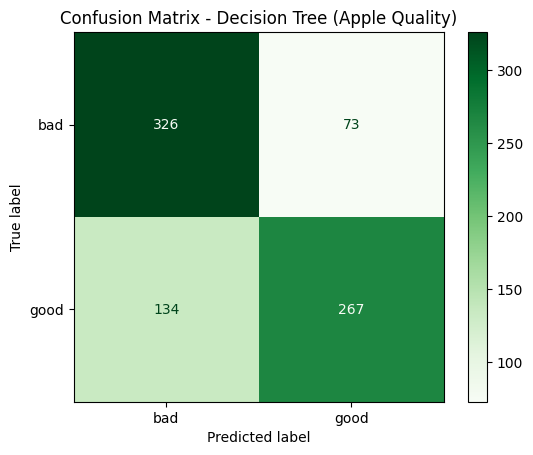

              precision    recall  f1-score   support

         0.0       0.71      0.82      0.76       399
         1.0       0.79      0.67      0.72       401

    accuracy                           0.74       800
   macro avg       0.75      0.74      0.74       800
weighted avg       0.75      0.74      0.74       800



In [102]:
# confusion matrix del decision tree
cm_tree = confusion_matrix(y_test, y_pred_tree)

# Visualizzazione
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['bad', 'good'])
disp.plot(cmap=plt.cm.Greens) # Usando il verde per distinguerlo dai test precedenti
plt.title('Confusion Matrix - Decision Tree (Apple Quality)')
plt.show()

# Print del report per vedere Precision e Recall
print(classification_report(y_test, y_pred_tree))


Prima di tutto si nota che l'accuracy è rimasta uguale nonostante il modello sia cambiato.

Questo modello rispetto al precedente è più bravo a identificare le mele cattive, ne ha identificate correttamente l'82%, ovvero 329 su 399, come si vede anche dal valore "recall" di 0.82.
I falsi positivi sono molti meno, 73, contro i 114 di prima, quindi meno mele cattive sono erroneamente classificate come buone.

Sulle mele buone invece la performance è peggiore (recall 0.67). Questa volta ben 134 mele sono state classificate erroneamente come cattive, quindi ci sono stati più sprechi.

### Feature importance

Si analizza la **feature importance** dell'albero: indica quanto ogni caratteristica (dimensione, peso, dolcezza, ecc.) ha contribuito a ridurre l'impurità nei nodi durante la costruzione.

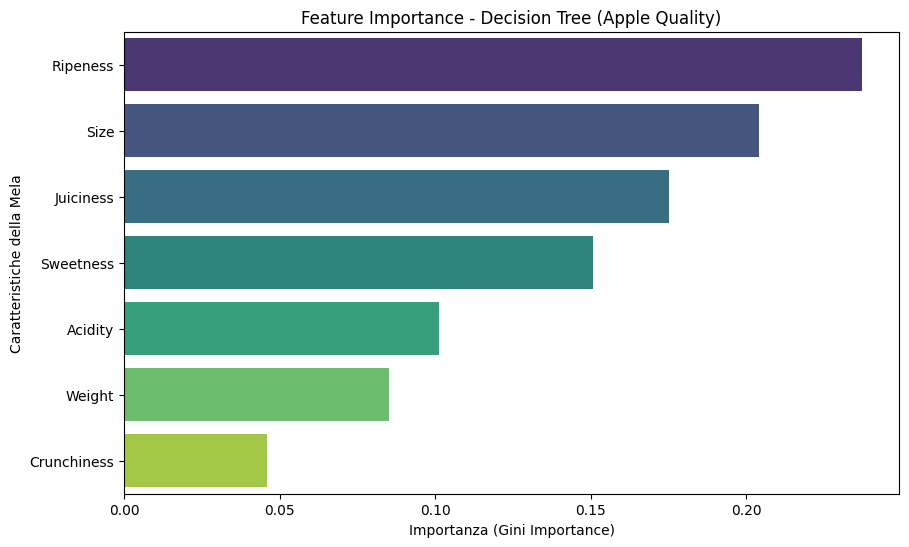

In [105]:
# codice per la feature importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

X_classification_features = classification_dataset.drop(['Quality', 'A_id'], axis=1, errors='ignore')

# 1. Estrazione dal modello
importances = decision_tree.feature_importances_
feature_names = X_classification_features.columns

# 2. Creazione di un  DataFrame per facilitare la visualizzazione
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 3. DataFrame ordinato dal più importante al meno importante
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. Visualizzazione grafica
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title('Feature Importance - Decision Tree (Apple Quality)')
plt.xlabel('Importanza (Gini Importance)')
plt.ylabel('Caratteristiche della Mela')
plt.show()

Questo grafico indica quanto i vari campi aiutano il modello a distinguere una mela buona da una cattiva. Si nota che quelli che contribuiscono maggiormente sono la maturazione e le dimensioni della mela, mentre croccantezza e peso contano relativamente poco.

## K-Means Clustering

Si passa al clustering non supervisionato. La label `Quality` viene rimossa: l'obiettivo è verificare se le mele si raggruppano naturalmente in cluster coerenti con la qualità, senza che il modello la conosca a priori.

In [108]:
clustering_dataset = classification_dataset.drop(columns=['Quality'])

Come primo tentativo si imposta **k=2**, ipotizzando che i dati si separino nettamente in due gruppi corrispondenti alle due classi.

In [110]:
# codice per trainare il modello con K-Means Clustering
from sklearn.cluster import KMeans

# 1. Inizializzazione del modello con 2 cluster
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)

# 2. Addestramento e assegnazione dei cluster
clusters = kmeans.fit_predict(X)

# 3. Aggiungiamo i risultati al dataset per l'analisi
X_clustered = X.copy()
X_clustered['Cluster'] = clusters

print(X_clustered['Cluster'].value_counts())

Cluster
0    2329
1    1671
Name: count, dtype: int64


Per testare il modello si classifica una mela con caratteristiche note e si verifica a quale cluster viene assegnata.

In [112]:
import pandas as pd

# 1. Dati della nuova mela
dati_nuova_mela = [[0.5, -1.2, 2.3, -0.5, 1.8, 0.4, -0.2]]

# 2. DataFrame con i nomi delle colonne di X
nuova_mela_df = pd.DataFrame(dati_nuova_mela, columns=X.columns)

# 3. Predizione del cluster
cluster_assegnato = kmeans.predict(nuova_mela_df)

print(f"La nuova mela è stata assegnata al Cluster: {cluster_assegnato[0]}")

La nuova mela è stata assegnata al Cluster: 1


In [113]:
# Crea una tabella per vedere come si sovrappongono Cluster e Quality
df_analisi = pd.DataFrame({'Cluster': clusters, 'Quality': classification_dataset['Quality']})
print(pd.crosstab(df_analisi['Cluster'], df_analisi['Quality']))

Quality   0.0   1.0
Cluster            
0        1314  1015
1         682   989


Con k=2 i cluster non corrispondono in modo pulito alle due categorie: entrambi contengono un mix simile di mele buone e cattive. La mela di test viene assegnata al cluster con leggera prevalenza di mele buone, ma la separazione non è affidabile.

Si prova con **k=3** per verificare se un cluster intermedio migliora la separazione.

In [116]:
# Inizializzazione con 3 cluster
kmeans_3 = KMeans(n_clusters=3, n_init=10, random_state=42)

# Addestramento
clusters_3 = kmeans_3.fit_predict(X)

# Aggiunta dei nuovi cluster al DataFrame per l'analisi
X_clustered_3 = X.copy()
X_clustered_3['Cluster_3'] = clusters_3

print("Distribuzione dei campioni nei 3 cluster:")
print(X_clustered_3['Cluster_3'].value_counts())

Distribuzione dei campioni nei 3 cluster:
Cluster_3
0    1547
1    1254
2    1199
Name: count, dtype: int64


In [117]:
# Predizione con il nuovo modello a 3 cluster
cluster_assegnato_3 = kmeans_3.predict(nuova_mela_df)

print(f"Con k=3, la nuova mela appartiene al Cluster: {cluster_assegnato_3[0]}")

Con k=3, la nuova mela appartiene al Cluster: 2


In [118]:
# di nuovo il controllo incrociato con la colonna Quality

df_analisi_3 = pd.DataFrame({'Cluster_3': clusters_3, 'Quality': classification_dataset['Quality']})
print(pd.crosstab(df_analisi_3['Cluster_3'], df_analisi_3['Quality']))

Quality     0.0  1.0
Cluster_3           
0          1036  511
1           493  761
2           467  732


Con k=3 la separazione migliora: un cluster è composto prevalentemente da mele cattive, gli altri due da mele buone. La mela di test viene classificata come probabilmente buona. Si cerca ora il numero ottimale di cluster con il metodo del gomito.

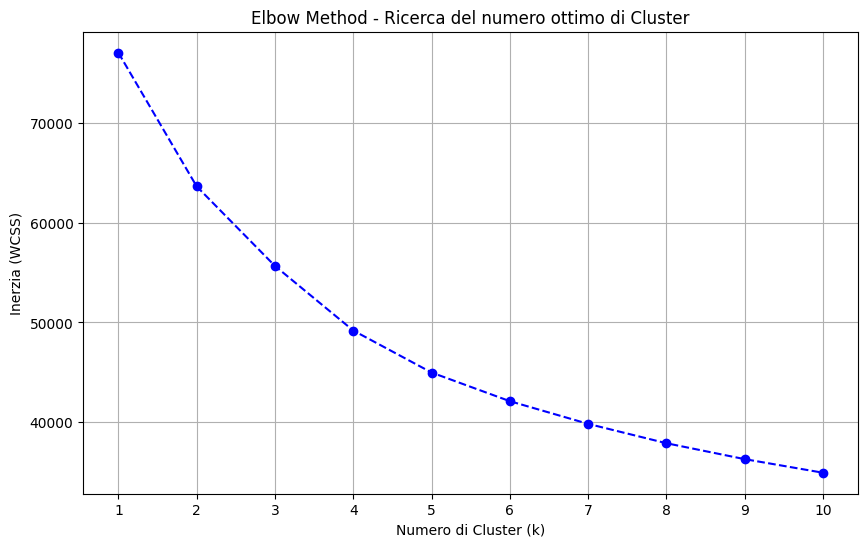

In [120]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Preparazione dati (solo numerici e senza NaN)
# Se hai aggiunto colonne come 'Cluster_3' in precedenza, dobbiamo rimuoverle per il test
X_numeric = X.select_dtypes(include=[np.number])

inertia = []
K_range = range(1, 11) # Test da 1 a 10 cluster

# 2. Ciclo per calcolare l'inerzia
for k in K_range:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    model.fit(X_numeric)
    inertia.append(model.inertia_)

# 3. Visualizzazione del grafico
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method - Ricerca del numero ottimo di Cluster')
plt.xlabel('Numero di Cluster (k)')
plt.ylabel('Inerzia (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

Il grafico mostra un cambio di pendenza evidente tra k=2 e k=3: aggiungere ulteriori cluster non porta un guadagno proporzionale nella riduzione dell'inerzia. **k=3** è il numero ottimale di cluster per questo dataset.

---


# Analisi conclusiva e considerazioni

L'analisi si è articolata in due parti distinte, ciascuna dedicata a un dataset e a una famiglia di problemi di Machine Learning.

## Metriche di valutazione

Per misurare l'efficacia dei modelli sono state adottate le seguenti metriche:

- $MSE\ (Mean\ Squared\ Error)$: media dei quadrati degli errori; penalizza fortemente gli outlier.

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

- $MAE\ (Mean\ Absolute\ Error)$: media delle differenze assolute tra valori reali e predetti; fornisce un'idea immediata dell'errore medio del modello.

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

- $R^2$: proporzione della varianza spiegata dal modello. Varia da 0 a 1 (valori negativi indicano un modello peggiore della semplice media).

---

## Parte 1 — Supermarket Sales

### Regressione sul Rating

Sono stati confrontati tre modelli per prevedere il Rating delle transazioni:

- **Linear Regression** (MSE: 3.11, MAE: 1.52): il miglior compromesso; il modello sbaglia in media di circa 1.5 punti.
- **Polynomial Regression** (MSE: 3.45, MAE: 1.57): non ha apportato miglioramenti, suggerendo che la relazione tra le feature non sia intrinsecamente non lineare.
- **Random Forest** (MSE: 3.57, MAE: 1.61): performance leggermente inferiori, probabilmente per la natura prevalentemente categorica delle variabili o per l'assenza di tuning.

### Analisi delle serie temporali

L'analisi temporale del gross income ha prodotto risultati negativi sia con la Regressione Lineare che con XGBoost (R² negativo o prossimo a zero). L'assenza di stagionalità o trend definiti suggerisce che il volume delle vendite dipenda da variabili esterne non presenti nel dataset (meteo, promozioni, concorrenza). L'analisi del gross income per categoria merceologica ha invece evidenziato una distribuzione equilibrata tra i reparti, con Food and Beverage in leggero vantaggio.

---

## Parte 2 — Apple Quality

### Classificazione supervisionata

- **Logistic Regression** (accuracy: 74%): risultati accettabili. Il modello separa discretamente le due classi, ma il 26% di errore riflette la non-linearità dei dati.
- **Decision Tree** (accuracy: 74%): stessa accuratezza complessiva, ma distribuzione degli errori diversa. Il modello è più efficace nell'identificare le mele cattive (recall 0.82 sulla classe "bad"), riducendo i falsi positivi da 114 a 73 rispetto alla Logistic Regression. Contropartita: più falsi negativi (134 mele buone scartate).

### Clustering non supervisionato

Il K-Means Clustering ha confermato che i dati non si separano nettamente in 2 cluster omogenei per qualità. Con k=3 la suddivisione risulta più pulita, suggerendo l'esistenza di una categoria intermedia di mele con caratteristiche miste.
